# 스트리밍 알고리즘 비교실험 (Bloom Filter / Count-Min Sketch)

빅데이터분석 과제 — 스트리밍 알고리즘 2종 구현 및 정확도·메모리 트레이드오프 분석

이 노트북은 다음을 순서대로 수행합니다.
1. 합성 클릭스트림 데이터셋(1,000,000건) 생성
2. Bloom Filter / Count-Min Sketch 직접 구현
3. Ground Truth(set, Counter)와 비교하는 실험 함수 정의
4. 기본 파라미터 실험 실행
5. 파라미터 비교 실험 실행
6. 결과 시각화

## 1. 라이브러리 설치

In [1]:
!pip install mmh3 bitarray -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 3.8 MB/s eta 0:00:00


## 2. 데이터셋 생성

실제 서비스 클릭스트림과 유사한 통계적 특성(Zipf 분포, long-tail)을 갖도록
합성 데이터셋을 생성합니다. 총 1,000,000건, page_id는 최대 20,000종입니다.

In [2]:
import csv
import numpy as np

np.random.seed(42)

N_RECORDS = 1_000_000
N_UNIQUE_USERS = 50_000
N_UNIQUE_PAGES = 20_000
ZIPF_A_USER = 1.3
ZIPF_A_PAGE = 1.2
EVENT_TYPES = ["view", "click", "add_to_cart", "purchase", "search"]
EVENT_PROBS = [0.55, 0.25, 0.10, 0.05, 0.05]

out_path = "clickstream.csv"

with open(out_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["timestamp", "user_id", "page_id", "event_type"])

    CHUNK = 100_000
    written = 0
    ts = 0
    while written < N_RECORDS:
        n = min(CHUNK, N_RECORDS - written)
        user_ranks = np.clip(np.random.zipf(ZIPF_A_USER, size=n), 1, N_UNIQUE_USERS)
        page_ranks = np.clip(np.random.zipf(ZIPF_A_PAGE, size=n), 1, N_UNIQUE_PAGES)
        event_idx = np.random.choice(len(EVENT_TYPES), size=n, p=EVENT_PROBS)

        for i in range(n):
            writer.writerow([ts, f"user_{user_ranks[i]-1}", f"page_{page_ranks[i]-1}", EVENT_TYPES[event_idx[i]]])
            ts += 1
        written += n
        print(f"{written:,} / {N_RECORDS:,} 완료")

print("데이터셋 생성 완료:", out_path)

100,000 / 1,000,000 완료
200,000 / 1,000,000 완료
300,000 / 1,000,000 완료
400,000 / 1,000,000 완료
500,000 / 1,000,000 완료
600,000 / 1,000,000 완료
700,000 / 1,000,000 완료
800,000 / 1,000,000 완료
900,000 / 1,000,000 완료
1,000,000 / 1,000,000 완료
데이터셋 생성 완료: clickstream.csv


## 3. Bloom Filter 구현

길이 m bit의 비트 배열과 k개의 해시 함수(mmh3에 서로 다른 seed)를 사용하여
원소 포함 여부를 근사 판정합니다. False Negative는 발생하지 않으며,
False Positive만 발생할 수 있습니다.

In [3]:
import mmh3
from bitarray import bitarray

class BloomFilter:
    def __init__(self, m_bits: int, k_hashes: int):
        self.m = m_bits
        self.k = k_hashes
        self.bits = bitarray(m_bits)
        self.bits.setall(0)

    def _hashes(self, item: str):
        for i in range(self.k):
            yield mmh3.hash(item, seed=i) % self.m

    def add(self, item: str):
        for idx in self._hashes(item):
            self.bits[idx] = 1

    def __contains__(self, item: str) -> bool:
        return all(self.bits[idx] for idx in self._hashes(item))

    def memory_bytes(self) -> int:
        return self.bits.buffer_info()[1]

## 4. Count-Min Sketch 구현

depth(d) x width(w) 크기의 2차원 카운터 배열을 사용하여 항목별 빈도를
근사 추정합니다. 추정값은 d개 행의 카운터 중 최솟값(min)으로, 항상 실제
빈도 이상(overestimate)입니다.

In [4]:
import numpy as np

class CountMinSketch:
    def __init__(self, width: int, depth: int):
        self.w = width
        self.d = depth
        self.table = np.zeros((depth, width), dtype=np.int64)

    def _indices(self, item: str):
        for row in range(self.d):
            yield row, mmh3.hash(item, seed=row) % self.w

    def add(self, item: str, count: int = 1):
        for row, col in self._indices(item):
            self.table[row, col] += count

    def estimate(self, item: str) -> int:
        return min(self.table[row, col] for row, col in self._indices(item))

    def memory_bytes(self) -> int:
        return self.table.nbytes

## 5. 실험 함수 정의

각 알고리즘에 대해 Ground Truth(set, Counter)와 비교하는 실험 함수를
정의합니다. 데이터는 csv.DictReader로 한 줄씩 스트림 처리합니다.

In [5]:
import time, sys, csv, json
from collections import Counter

DATA_PATH = "clickstream.csv"

def run_bloom_filter_experiment(m_bits, k_hashes, label=""):
    bf = BloomFilter(m_bits=m_bits, k_hashes=k_hashes)
    ground_truth_set = set()
    total = 0
    false_positives = 0
    actual_new_count = 0

    start_time = time.perf_counter()
    with open(DATA_PATH, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            page_id = row["page_id"]
            total += 1
            gt_is_new = page_id not in ground_truth_set
            bf_says_seen = page_id in bf
            if gt_is_new:
                actual_new_count += 1
                if bf_says_seen:
                    false_positives += 1
            ground_truth_set.add(page_id)
            bf.add(page_id)
    elapsed = time.perf_counter() - start_time

    fp_rate = false_positives / actual_new_count if actual_new_count else 0.0
    bf_memory = bf.memory_bytes()
    gt_memory = sys.getsizeof(ground_truth_set) + sum(sys.getsizeof(s) for s in ground_truth_set)

    return {
        "label": label, "m_bits": m_bits, "k_hashes": k_hashes, "total_records": total,
        "unique_items_gt": len(ground_truth_set), "false_positives": false_positives,
        "false_positive_rate": fp_rate, "bloom_memory_bytes": bf_memory,
        "ground_truth_memory_bytes": gt_memory, "elapsed_sec": elapsed,
        "throughput_per_sec": total / elapsed,
    }


def run_cms_experiment(width, depth, label=""):
    cms = CountMinSketch(width=width, depth=depth)
    ground_truth_counter = Counter()
    total = 0

    start_time = time.perf_counter()
    with open(DATA_PATH, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            page_id = row["page_id"]
            total += 1
            cms.add(page_id)
            ground_truth_counter[page_id] += 1
    elapsed = time.perf_counter() - start_time

    top_items = ground_truth_counter.most_common(50)
    rel_errors = []
    for item, true_count in top_items:
        est_count = cms.estimate(item)
        rel_errors.append(abs(est_count - true_count) / true_count)

    avg_rel_error = sum(rel_errors) / len(rel_errors)
    max_rel_error = max(rel_errors)
    cms_memory = cms.memory_bytes()
    gt_memory = sys.getsizeof(ground_truth_counter) + sum(sys.getsizeof(k) + sys.getsizeof(v) for k, v in ground_truth_counter.items())

    return {
        "label": label, "width": width, "depth": depth, "total_records": total,
        "unique_items_gt": len(ground_truth_counter), "avg_relative_error_top50": avg_rel_error,
        "max_relative_error_top50": max_rel_error, "cms_memory_bytes": cms_memory,
        "ground_truth_memory_bytes": gt_memory, "elapsed_sec": elapsed,
        "throughput_per_sec": total / elapsed,
    }

## 6. 기본 파라미터 실험

- Bloom Filter: m=200,000 bits, k=4
- Count-Min Sketch: width=2,000, depth=4

In [6]:
bf_result = run_bloom_filter_experiment(m_bits=200_000, k_hashes=4, label="default")
print(json.dumps(bf_result, indent=2, ensure_ascii=False))

cms_result = run_cms_experiment(width=2000, depth=4, label="default")
print(json.dumps(cms_result, indent=2, ensure_ascii=False))

with open("results_default.json", "w", encoding="utf-8") as f:
    json.dump({"bloom_filter": bf_result, "count_min_sketch": cms_result}, f, indent=2, ensure_ascii=False)

{
  "label": "default",
  "m_bits": 200000,
  "k_hashes": 4,
  "total_records": 1000000,
  "unique_items_gt": 18140,
  "false_positives": 44,
  "false_positive_rate": 0.0024255788313120178,
  "bloom_memory_bytes": 25000,
  "ground_truth_memory_bytes": 1438661,
  "elapsed_sec": 6.236599153,
  "throughput_per_sec": 160343.79883449277
}
{
  "label": "default",
  "width": 2000,
  "depth": 4,
  "total_records": 1000000,
  "unique_items_gt": 18140,
  "avg_relative_error_top50": 0.010094767138035006,
  "max_relative_error_top50": 0.06320541760722348,
  "cms_memory_bytes": 64000,
  "ground_truth_memory_bytes": 1837245,
  "elapsed_sec": 4.365981660000003,
  "throughput_per_sec": 229043.56405381678
}


## 7. 파라미터 비교 실험 (기타 +3점 항목)

- Bloom Filter: m 변화(k=4 고정) / k 변화(m=200,000 고정)
- Count-Min Sketch: width 변화(depth=4 고정) / depth 변화(width=2,000 고정)

총 14개 조합을 처리하므로 1~2분 정도 소요될 수 있습니다.

In [7]:
results = {"bloom_m": [], "bloom_k": [], "cms_width": [], "cms_depth": []}

print("### Bloom Filter - m 변화 (k=4) ###")
for m in [25_000, 100_000, 200_000, 400_000, 1_600_000]:
    r = run_bloom_filter_experiment(m_bits=m, k_hashes=4, label=f"m={m}")
    print(f"m={m:>9,} | FP rate={r['false_positive_rate']:.5f} | memory={r['bloom_memory_bytes']:>8,} B | time={r['elapsed_sec']:.2f}s")
    results["bloom_m"].append(r)

print("\n### Bloom Filter - k 변화 (m=200,000) ###")
for k in [1, 2, 4, 8, 12]:
    r = run_bloom_filter_experiment(m_bits=200_000, k_hashes=k, label=f"k={k}")
    print(f"k={k:>2} | FP rate={r['false_positive_rate']:.5f} | memory={r['bloom_memory_bytes']:>8,} B | time={r['elapsed_sec']:.2f}s")
    results["bloom_k"].append(r)

print("\n### CMS - width 변화 (depth=4) ###")
for w in [250, 1000, 2000, 4000, 16000]:
    r = run_cms_experiment(width=w, depth=4, label=f"width={w}")
    print(f"width={w:>6} | avg_err={r['avg_relative_error_top50']:.5f} | max_err={r['max_relative_error_top50']:.5f} | memory={r['cms_memory_bytes']:>8,} B | time={r['elapsed_sec']:.2f}s")
    results["cms_width"].append(r)

print("\n### CMS - depth 변화 (width=2000) ###")
for d in [1, 2, 4, 8, 12]:
    r = run_cms_experiment(width=2000, depth=d, label=f"depth={d}")
    print(f"depth={d:>2} | avg_err={r['avg_relative_error_top50']:.5f} | max_err={r['max_relative_error_top50']:.5f} | memory={r['cms_memory_bytes']:>8,} B | time={r['elapsed_sec']:.2f}s")
    results["cms_depth"].append(r)

with open("results_param.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

### Bloom Filter - m 변화 (k=4) ###
m=   25,000 | FP rate=0.35204 | memory=   3,125 B | time=3.61s
m=  100,000 | FP rate=0.01913 | memory=  12,500 B | time=3.61s
m=  200,000 | FP rate=0.00243 | memory=  25,000 B | time=4.13s
m=  400,000 | FP rate=0.00017 | memory=  50,000 B | time=3.53s
m=1,600,000 | FP rate=0.00000 | memory= 200,000 B | time=3.61s

### Bloom Filter - k 변화 (m=200,000) ###
k= 1 | FP rate=0.04250 | memory=  25,000 B | time=3.18s
k= 2 | FP rate=0.00910 | memory=  25,000 B | time=2.94s
k= 4 | FP rate=0.00243 | memory=  25,000 B | time=3.57s
k= 8 | FP rate=0.00105 | memory=  25,000 B | time=5.34s
k=12 | FP rate=0.00050 | memory=  25,000 B | time=5.96s

### CMS - width 변화 (depth=4) ###
width=   250 | avg_err=0.17765 | max_err=0.61066 | memory=   8,000 B | time=4.36s
width=  1000 | avg_err=0.02972 | max_err=0.11450 | memory=  32,000 B | time=3.82s
width=  2000 | avg_err=0.01009 | max_err=0.06321 | memory=  64,000 B | time=3.94s
width=  4000 | avg_err=0.00361 | max_err=0.02303 |

## 8. 결과 시각화

기본 실험 결과와 파라미터 비교 실험 결과를 바탕으로 차트를 생성합니다.
생성된 PNG 파일은 Colab 좌측 파일 탐색기에서 다운로드하여 보고서에
첨부할 수 있습니다.

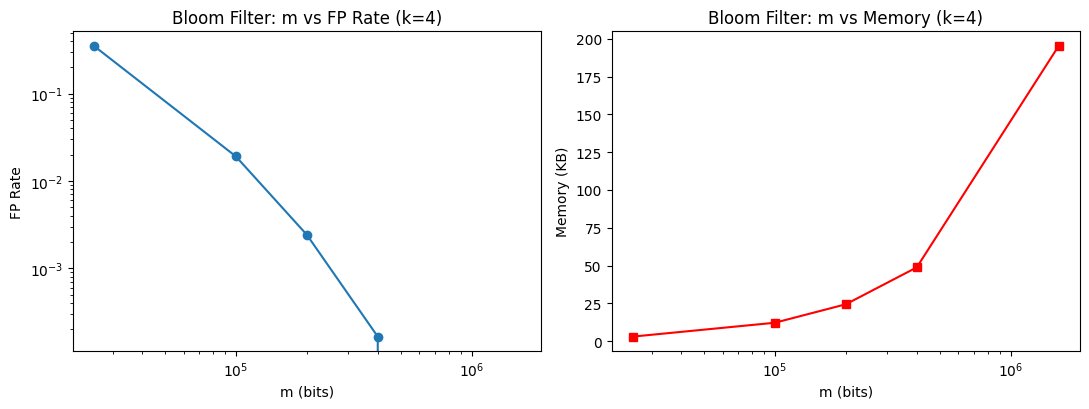

In [8]:
import matplotlib.pyplot as plt

with open("results_param.json", encoding="utf-8") as f:
    data = json.load(f)
with open("results_default.json", encoding="utf-8") as f:
    default = json.load(f)

# --- Bloom Filter: m vs FP rate / memory ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ms = [r["m_bits"] for r in data["bloom_m"]]
fps = [r["false_positive_rate"] for r in data["bloom_m"]]
mems = [r["bloom_memory_bytes"] / 1024 for r in data["bloom_m"]]
axes[0].plot(ms, fps, marker="o")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("m (bits)"); axes[0].set_ylabel("FP Rate")
axes[0].set_title("Bloom Filter: m vs FP Rate (k=4)")
axes[1].plot(ms, mems, marker="s", color="red")
axes[1].set_xscale("log")
axes[1].set_xlabel("m (bits)"); axes[1].set_ylabel("Memory (KB)")
axes[1].set_title("Bloom Filter: m vs Memory (k=4)")
plt.tight_layout(); plt.savefig("chart_bloom_m.png", dpi=130); plt.show()

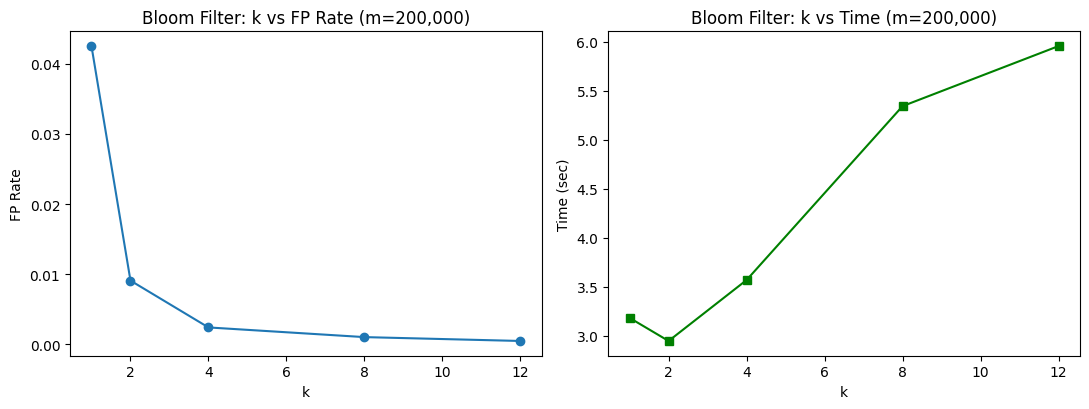

In [9]:
# --- Bloom Filter: k vs FP rate / time ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ks = [r["k_hashes"] for r in data["bloom_k"]]
fps_k = [r["false_positive_rate"] for r in data["bloom_k"]]
times_k = [r["elapsed_sec"] for r in data["bloom_k"]]
axes[0].plot(ks, fps_k, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("FP Rate")
axes[0].set_title("Bloom Filter: k vs FP Rate (m=200,000)")
axes[1].plot(ks, times_k, marker="s", color="green")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Time (sec)")
axes[1].set_title("Bloom Filter: k vs Time (m=200,000)")
plt.tight_layout(); plt.savefig("chart_bloom_k.png", dpi=130); plt.show()

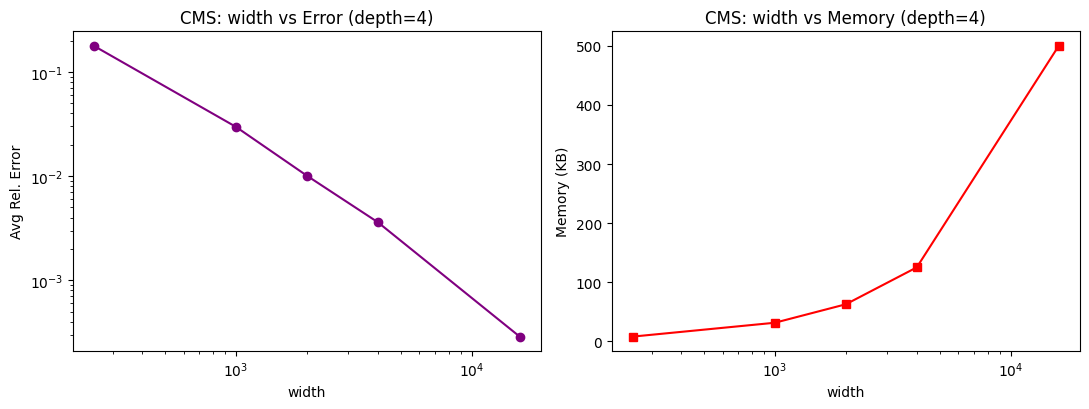

In [10]:
# --- CMS: width vs error / memory ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ws = [r["width"] for r in data["cms_width"]]
errs_w = [r["avg_relative_error_top50"] for r in data["cms_width"]]
mems_w = [r["cms_memory_bytes"] / 1024 for r in data["cms_width"]]
axes[0].plot(ws, errs_w, marker="o", color="purple")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("width"); axes[0].set_ylabel("Avg Rel. Error")
axes[0].set_title("CMS: width vs Error (depth=4)")
axes[1].plot(ws, mems_w, marker="s", color="red")
axes[1].set_xscale("log")
axes[1].set_xlabel("width"); axes[1].set_ylabel("Memory (KB)")
axes[1].set_title("CMS: width vs Memory (depth=4)")
plt.tight_layout(); plt.savefig("chart_cms_width.png", dpi=130); plt.show()

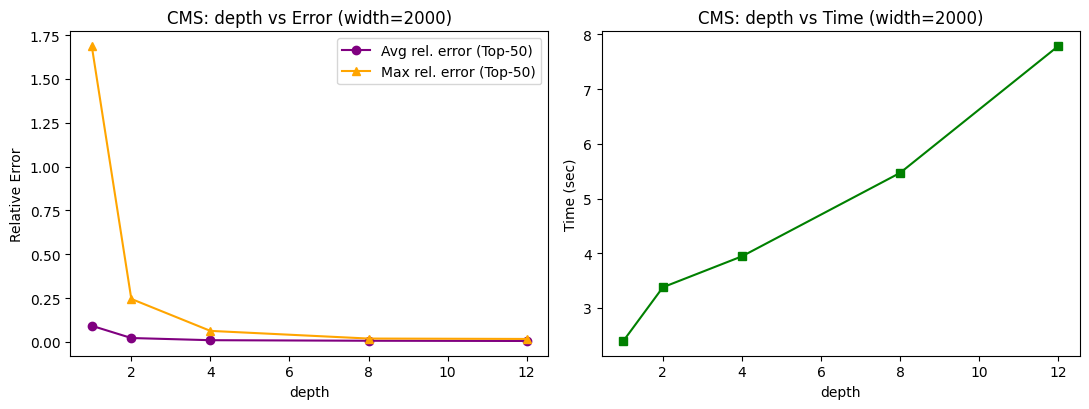

In [11]:
# --- CMS: depth vs error / time ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ds = [r["depth"] for r in data["cms_depth"]]
errs_d = [r["avg_relative_error_top50"] for r in data["cms_depth"]]
maxerrs_d = [r["max_relative_error_top50"] for r in data["cms_depth"]]
times_d = [r["elapsed_sec"] for r in data["cms_depth"]]
axes[0].plot(ds, errs_d, marker="o", color="purple", label="Avg rel. error (Top-50)")
axes[0].plot(ds, maxerrs_d, marker="^", color="orange", label="Max rel. error (Top-50)")
axes[0].set_xlabel("depth"); axes[0].set_ylabel("Relative Error")
axes[0].set_title("CMS: depth vs Error (width=2000)")
axes[0].legend()
axes[1].plot(ds, times_d, marker="s", color="green")
axes[1].set_xlabel("depth"); axes[1].set_ylabel("Time (sec)")
axes[1].set_title("CMS: depth vs Time (width=2000)")
plt.tight_layout(); plt.savefig("chart_cms_depth.png", dpi=130); plt.show()

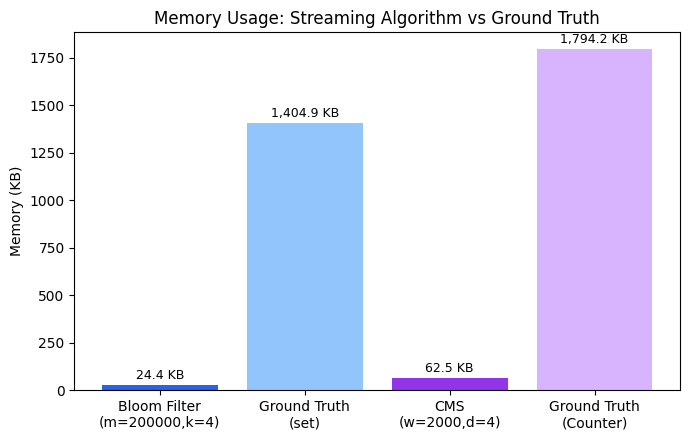

In [12]:
# --- 메모리 사용량 종합 비교 (Bloom Filter / CMS vs Ground Truth) ---
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Bloom Filter\n(m=200000,k=4)", "Ground Truth\n(set)", "CMS\n(w=2000,d=4)", "Ground Truth\n(Counter)"]
values = [
    default["bloom_filter"]["bloom_memory_bytes"] / 1024,
    default["bloom_filter"]["ground_truth_memory_bytes"] / 1024,
    default["count_min_sketch"]["cms_memory_bytes"] / 1024,
    default["count_min_sketch"]["ground_truth_memory_bytes"] / 1024,
]
colors = ["#2563eb", "#93c5fd", "#9333ea", "#d8b4fe"]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Memory (KB)")
ax.set_title("Memory Usage: Streaming Algorithm vs Ground Truth")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(values)*0.01, f"{v:,.1f} KB", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.savefig("chart_memory_comparison.png", dpi=130); plt.show()

## 9. 결과 파일 확인

생성된 결과 파일 목록입니다. `results_default.json`, `results_param.json`은
보고서의 표에 사용된 수치 데이터이며, `chart_*.png`는 보고서에 삽입할
차트 이미지입니다.

In [13]:
import os
for f in sorted(os.listdir(".")):
    if f.startswith(("results_", "chart_")):
        print(f, "-", os.path.getsize(f), "bytes")

chart_bloom_k.png - 50765 bytes
chart_bloom_m.png - 49370 bytes
chart_cms_depth.png - 60655 bytes
chart_cms_width.png - 50983 bytes
chart_memory_comparison.png - 40896 bytes
results_default.json - 792 bytes
results_param.json - 8176 bytes
